In [1]:
suppressPackageStartupMessages({
    library(reticulate)
    library(ggplot2)
    library(Seurat)
    library(dplyr)
    library(tidyr)
    library(tibble)
    library(stringr)
    library(lme4)
    library(numDeriv)
    library(dittoSeq)
    library(future)
    library(data.table)
    library(scales)
    plan("multisession", workers = 4)
    options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”


In [2]:
malignant <- readRDS('/projects/0/einf2548/cruiz/dmg/data/malignant_rna.rds')
malignant

An object of class Seurat 
19248 features across 291695 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [9]:
library(readxl)
file_path <- "/projects/0/einf2548/cruiz/dmg/notebooks/nmf/data/Venkataramani_ Invasiveness_signature.xlsx"
data <- read_excel(file_path, sheet = "Tab 2-Supplementary Table 2a")
data

Gene,S24_statistic,S24_parameter,S24_p.value,S24-correlation coefficient estimate,S24_null.value,S24_alternative,S24_method,P3XX_statistic,P3XX_parameter,⋯,P3XX_alternative,P3XX_method,T269_statistic,T269_parameter,T269_p.value,T269-correlation coefficient estimate,T269_null.value,T269_alternative,T269_method,Direction
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,⋯,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
AC114730.3,-27.5361968,15627,4.913516e-163,-0.215118384,0,two.sided,Pearson's product-moment correlation,-13.971037,3013,⋯,two.sided,Pearson's product-moment correlation,-7.993750,17176,1.391466e-15,-0.06088119,0,two.sided,Pearson's product-moment correlation,Anticorrelated
ACAT2,26.3135178,15627,2.361662e-149,0.205980829,0,two.sided,Pearson's product-moment correlation,18.847910,3013,⋯,two.sided,Pearson's product-moment correlation,8.610422,17176,7.900615e-18,0.06555837,0,two.sided,Pearson's product-moment correlation,Correlated
ACTB,30.6877422,15627,7.185270e-201,0.238407673,0,two.sided,Pearson's product-moment correlation,19.693504,3013,⋯,two.sided,Pearson's product-moment correlation,28.315011,17176,2.017107e-172,0.21117825,0,two.sided,Pearson's product-moment correlation,Correlated
ANAPC11,39.2248617,15627,0.000000e+00,0.299386392,0,two.sided,Pearson's product-moment correlation,23.380055,3013,⋯,two.sided,Pearson's product-moment correlation,13.202385,17176,1.325460e-39,0.10023026,0,two.sided,Pearson's product-moment correlation,Correlated
ANXA2,69.2794039,15627,0.000000e+00,0.484736496,0,two.sided,Pearson's product-moment correlation,1.471536,3013,⋯,two.sided,Pearson's product-moment correlation,31.274489,17176,7.163232e-209,0.23211486,0,two.sided,Pearson's product-moment correlation,Correlated
AP2S1,31.2547087,15627,4.612903e-208,0.242555410,0,two.sided,Pearson's product-moment correlation,13.519309,3013,⋯,two.sided,Pearson's product-moment correlation,9.552745,17176,1.428953e-21,0.07269701,0,two.sided,Pearson's product-moment correlation,Correlated
ASCL1,-35.0028125,15627,1.738642e-258,-0.269634015,0,two.sided,Pearson's product-moment correlation,-11.623998,3013,⋯,two.sided,Pearson's product-moment correlation,-18.456694,17176,2.464027e-75,-0.13945317,0,two.sided,Pearson's product-moment correlation,Anticorrelated
ASPM,-7.9323265,15627,2.295602e-15,-0.063327186,0,two.sided,Pearson's product-moment correlation,13.879732,3013,⋯,two.sided,Pearson's product-moment correlation,33.972231,17176,6.804857e-245,0.25092360,0,two.sided,Pearson's product-moment correlation,Correlated
ATF3,33.9898968,15627,2.254784e-244,0.262375897,0,two.sided,Pearson's product-moment correlation,5.873370,3013,⋯,two.sided,Pearson's product-moment correlation,31.123962,17176,6.127660e-207,0.23105744,0,two.sided,Pearson's product-moment correlation,Correlated


In [10]:
invasiveness_sig <- list(data$Gene)
invasiveness_sig

[[1]]
  [1] "AC114730.3"  "ACAT2"       "ACTB"        "ANAPC11"     "ANXA2"      
  [6] "AP2S1"       "ASCL1"       "ASPM"        "ATF3"        "ATP1B3"     
 [11] "AURKA"       "AURKAIP1"    "AURKB"       "B2M"         "BCAN"       
 [16] "BCL7C"       "BIRC5"       "BTG1"        "BUB1"        "BUD31"      
 [21] "CALM1"       "CALM2"       "CASC5"       "CCDC109B"    "CCNA2"      
 [26] "CDCA3"       "CDK1"        "CDKN3"       "CENPA"       "CENPF"      
 [31] "CENPK"       "CFL1"        "CHCHD2"      "CHCHD3"      "CKAP2"      
 [36] "CKS1B"       "CLIC1"       "CLU"         "CNN3"        "COPRS"      
 [41] "COX5A"       "COX8A"       "CRYAB"       "CTNNAL1"     "CYR61"      
 [46] "DCX"         "DLGAP5"      "DLL1"        "DLL3"        "DNAJB1"     
 [51] "DNPH1"       "DTYMK"       "ECI1"        "EEF1B2"      "ETFB"       
 [56] "ETV1"        "FAM64A"      "FAM83D"      "FBXO5"       "FDPS"       
 [61] "FIBP"        "GAPDH"       "GFAP"        "GNB2"        "GPX4"       
 [66] "GSTP1"       "GTSE1"       "H2AFZ"       "HES6"        "HINT1"      
 [71] "HINT2"       "HIST1H4C"    "HJURP"       "HMGB2"       "HOPX"       
 [76] "ITGB1BP1"    "KCNQ1OT1"    "KIAA0101"    "KIF20A"      "KIF23"      
 [81] "KIF2C"       "KIFC1"       "KPNA2"       "LINC00152"   "LMNB1"      
 [86] "LRRN1"       "LSMD1"       "MAD2L1"      "MALAT1"      "MANF"       
 [91] "MARCKSL1"    "MEA1"        "MFNG"        "MIR4435-1HG" "MKI67"      
 [96] "MRPL37"      "MT-ND3"      "MT2A"        "MXD3"        "MYC"        
[101] "MZT2B"       "NCAPG"       "NDC80"       "NDUFA4"      "NDUFA6"     
[106] "NDUFS8"      "NEK2"        "NEU4"        "NGFRAP1"     "NMB"        
[111] "NUF2"        "NUSAP1"      "OLIG1"       "PBK"         "PCOLCE"     
[116] "PFN1"        "PHF19"       "PHPT1"       "PKM"         "POLR2I"     
[121] "PPIA"        "PRC1"        "PRR24"       "PSMA7"       "PSMB3"      
[126] "PSME2"       "PTN"         "PTTG1"       "PXMP2"       "RACGAP1"    
[131] "RBX1"        "RDX"         "RRM2"        "SGOL1"       "SGOL2"      
[136] "SHD"         "SHMT2"       "SIVA1"       "SLC25A5"     "SMC4"       
[141] "SOCS3"       "SOX4"        "SPARC"       "SPC25"       "SSBP4"      
[146] "STK17A"      "TAGLN2"      "TCF12"       "TCTEX1D2"    "TECR"       
[151] "TK1"         "TMEM147"     "TMEM54"      "TNFRSF12A"   "TNK2"       
[156] "TOP2A"       "TPI1"        "TPX2"        "TUBA1B"      "TUBA1C"     
[161] "TUBB2A"      "TUBB6"       "UBE2C"       "UBE2T"       "UQCC2"      
[166] "UQCR10"      "UQCRC1"      "UQCRQ"       "VIM"         "VMP1"       
[171] "ZFP36"       "ZWINT"

In [11]:
malignant <- UCell::AddModuleScore_UCell(
    obj = malignant,
    features = invasiveness_sig,
    ncores = 8,
    name = 'invasiveness'
    )

Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* AC114730.3,CASC5,CCDC109B,CYR61,FAM64A,KCNQ1OT1,KIAA0101,LINC00152,LSMD1,MALAT1,MIR4435-1HG,NGFRAP1,PRR24,SGOL1,SGOL2”


In [13]:
malignant$niches <- recode(malignant$MP_Assignment,
                          'MP4'='Stem-like',
                          'MP13'='Stem-like',
                          'MP11'='Stem-like',
                          'MP12'='Stem-like',
                          'MP2'='Stem-like',
                          'MP5'='Diff-like',
                          'MP3'='Diff-like',
                          'MP8'='Diff-like',
                          'MP7'='TE-associated',
                          'MP9'='TE-associated'
                          )

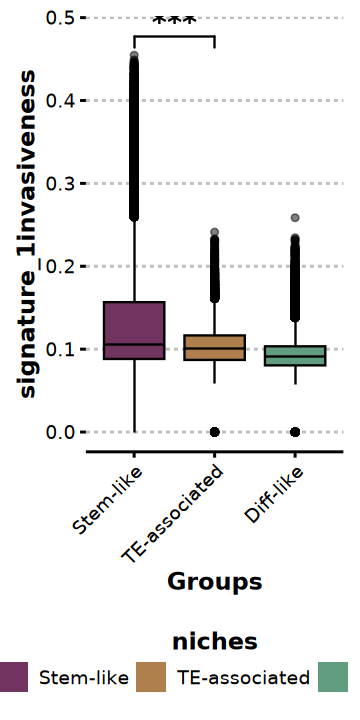

In [17]:
clustercols <- c("Stem-like"='#713461',
                'Diff-like'='#609d7f',
                 'TE-associated'='#ae7f4d',
                 'unresolved'='white'
                )

options(repr.plot.height = 6, repr.plot.width = 3)
SCpubr::do_BoxPlot(sample = subset(malignant, MP_Assignment!='unresolved'),
                   colors.use = clustercols,
                   feature = "signature_1invasiveness",
                   group.by = "niches",
                   use_test = TRUE,
                   map_signif_level = TRUE,
                   comparisons = list(c("Stem-like", "TE-associated")
                                     ),
                   order = TRUE)

In [18]:
ggsave('figures/boxplot_invasiveness_scoring_niches.pdf', height = 5.5, width =2)

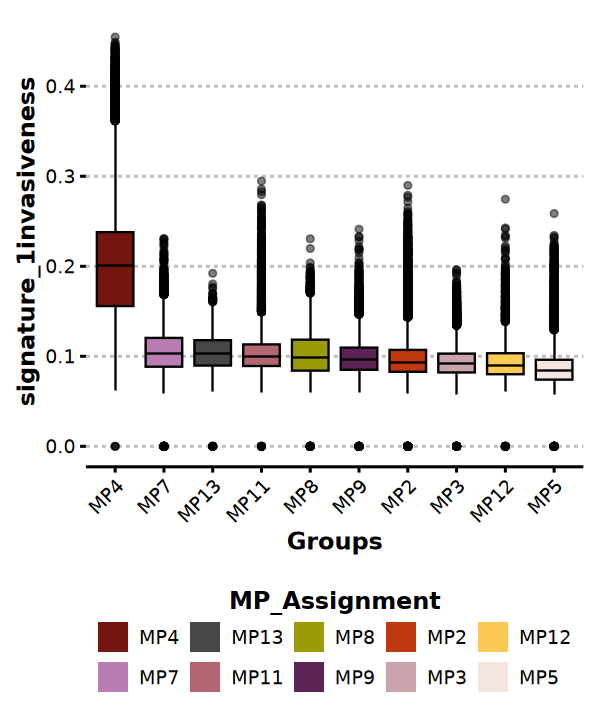

In [20]:
clustercols <- c("MP2" = "#c13910",
                  "MP3" = "#caa4ab",                    
                  "MP4" = "#74150f",                    
                  "MP5" = "#f4e5e1",                 
                  "MP7" = "#ba7db3",
                 "MP8"="#9a9b06",
                 "MP9"="#5c2454",
                 "MP11"="#b26671",
                 "MP12"="#fdc955",
                 "MP13"="#474747",
                'unresolved'='#f1f1f1')

options(repr.plot.height = 6, repr.plot.width = 5)
SCpubr::do_BoxPlot(sample = subset(malignant, MP_Assignment!='unresolved'),
                   colors.use = clustercols,
                   feature = "signature_1invasiveness",
                   group.by = "MP_Assignment",
                   order = TRUE)

In [21]:
ggsave('figures/boxplot_invasiveness_scoring.pdf', height = 5.5, width = 4.5)

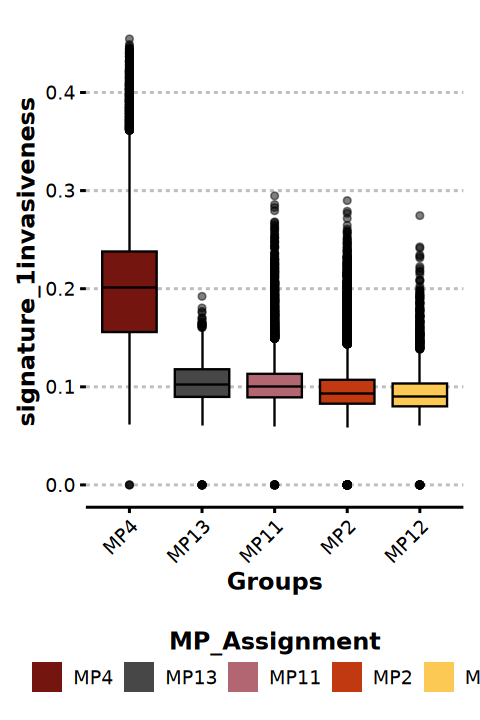

In [14]:
clustercols <- c("MP2" = "#c13910",
                  "MP3" = "#caa4ab",                    
                  "MP4" = "#74150f",                    
                  "MP5" = "#f4e5e1",                 
                  "MP7" = "#ba7db3",
                 "MP8"="#9a9b06",
                 "MP9"="#5c2454",
                 "MP11"="#b26671",
                 "MP12"="#fdc955",
                 "MP13"="#474747",
                'unresolved'='#f1f1f1')

options(repr.plot.height = 6, repr.plot.width = 4)
SCpubr::do_BoxPlot(sample = subset(malignant, niches %in% c('Stem-like')),
                   colors.use = clustercols,
                   feature = "signature_1invasiveness",
                   group.by = "MP_Assignment",
                   order = TRUE)

In [15]:
ggsave('figures/boxplot_invasiveness_scoring_stem-like.pdf', height = 5.5, width = 3)

In [15]:
MP_list = readRDS('data/robust_NMF_programs_malignant.rds')

In [19]:
MP_list

MP_1,MP_2,MP_3,MP_4,MP_5,MP_6,MP_7,MP_8,MP_9,MP_10,MP_11,MP_12
DIAPH3,CA10,SPARCL1,RPS18,BCAS1,VEGFA,GAP43,ARMC3,AQP4,HSPE1,CD44,SLIT1
RRM2,MMP16,CLU,RPL41,SIRT2,HILPDA,CAMK2D,DNAH6,CLU,HSPH1,ACTN1,EGFR
TOP2A,NXPH1,DCLK1,RPLP1,PKP4,SLC6A6,ITGA3,MAP3K19,ITM2C,USPL1,GAP43,GLCCI1
CENPF,LHFPL3,AQP4,RPS15,MBP,NDRG1,ADAMTS9,CFAP43,APOE,DNAJB1,HRH1,PAK3
ASPM,PCDH15,EEPD1,RPS4X,BMPER,FAM162A,HIVEP3,DNAH9,CST3,HSP90AA1,ELL2,BEST3
KNL1,DSCAM,KCNN3,RPL18A,CDK18,INSIG2,EMP1,VWA3A,B2M,HSPA1A,NAMPT,CHD7
TPX2,SEZ6L,ANOS1,RPL7A,SHROOM4,PDK1,GALR1,C6ORF118,CRYAB,HSPD1,CLIC4,KCNQ3
BRIP1,PDGFRA,SLC4A4,RPL13,ST18,GBE1,RASSF8,ZBBX,SPARC,CHORDC1,LPAR1,NKD1
KIF14,FGF12,DAAM2,RPL19,MYRF,SLC2A1,RGS17,C8ORF34,SPARCL1,HSPA1B,OSMR,SEZ6L
NUSAP1,SNTG1,APOE,RPL8,PPP1R16B,AKAP12,SPOCD1,SPATA17,AQP1,HSPA6,SAMD4A,BOC


In [16]:
gene_set <- as.data.frame(MP_list)[[4]]

In [18]:
malignant <- UCell::AddModuleScore_UCell(
    obj = malignant,
    features = list(gene_set),
    name = 'RG_like',
    ncores = 12,
    )

In [29]:
malignant@meta.data

,nCount_RNA,nFeature_RNA,nCount_RAW,nFeature_RAW,DF.class,DF.score,scDblFinder.class,scDblFinder.score,ID,SampleID,⋯,predicted.annotation_level_4.score,predicted.annotation_level_4,iCNV,cell_id,MP_Assignment,Material,signature_1invasiveness,signature_1RG_like,invasiveness1,RG_like1
,<dbl>,<int>,<dbl>,<int>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
BT042_pons_2_AGGCCACCATGGCCAC-1,1020,731,1179,836,Singlet,0.15217391,Singlet,0.05966683,T18-90532,BT042_pons_2,⋯,0.4575269,MES-like hypoxia/MHC,tumor,Differentiated_like_tumor,MP9,nuclei,0.06110465,0.00000000,-0.105876371,-0.4710264
BT042_pons_2_CCCTCAAAGTAGCTCT-1,897,673,1044,781,Singlet,0.15217391,Singlet,0.07683539,T18-90532,BT042_pons_2,⋯,0.6477115,MES-like hypoxia/MHC,tumor,Differentiated_like_tumor,MP9,nuclei,0.08790310,0.00000000,-0.018300616,-0.3938950
BT042_pons_2_CTCCGATTCGGCCTTT-1,847,613,994,709,Singlet,0.11739130,Singlet,0.02298219,T18-90532,BT042_pons_2,⋯,0.2757447,AC-like,tumor,Differentiated_like_tumor,unresolved,nuclei,0.08010271,0.00000000,-0.035691302,-0.3632311
BT042_pons_2_TGATCAGTCCTACAAG-1,827,637,1006,753,Singlet,0.12608696,Singlet,0.01525696,T18-90532,BT042_pons_2,⋯,0.3874710,OPC-like,tumor,Stem_like_tumor,MP11,nuclei,0.07444961,0.00000000,-0.052953666,-0.3797119
BT042_pons_2_ATCACTTAGACATGCG-1,627,504,828,655,Singlet,0.13043478,Singlet,0.03680524,T18-90532,BT042_pons_2,⋯,0.4341138,MES-like hypoxia/MHC,tumor,Differentiated_like_tumor,unresolved,nuclei,0.07198837,0.00000000,-0.049360618,-0.3417057
BT042_pons_2_GAAATGAGTACTAAGA-1,531,424,740,585,Singlet,0.10869565,Singlet,0.03842901,T18-90532,BT042_pons_2,⋯,0.4750826,MES-like hypoxia independent,tumor,Differentiated_like_tumor,unresolved,nuclei,0.06752907,0.00000000,-0.051013127,-0.3190066
BT042_pons_2_CATCCGTGTTAAGACA-1,541,424,740,593,Singlet,0.13478261,Singlet,0.03842901,T18-90532,BT042_pons_2,⋯,0.4961172,AC-like,tumor,Differentiated_like_tumor,MP3,nuclei,0.07254070,0.00000000,-0.026504490,-0.3472665
BT042_pons_2_TCTATCAGTGGAGGTT-1,527,432,737,582,Singlet,0.13478261,Singlet,0.01356047,T18-90532,BT042_pons_2,⋯,0.4594949,NPC-like OPC,tumor,Stem_like_tumor,unresolved,nuclei,0.09834690,0.00000000,0.052700071,-0.3026102
BT042_pons_2_TCTGGCTTCGAGAACG-1,278,230,505,422,Singlet,0.11304348,Singlet,0.03209129,T18-90532,BT042_pons_2,⋯,0.3498062,MES-like hypoxia independent,tumor,Differentiated_like_tumor,MP9,nuclei,0.06231395,0.00000000,-0.037447039,-0.1797796


In [21]:
metadata <- FetchData(malignant, vars = c("signature_1RG_like", "signature_1invasiveness"))
# Calculate correlation
correlation <- cor.test(metadata$signature_1RG_like, metadata$signature_1invasiveness)
R_value <- correlation$estimate
p_value <- correlation$p.value

In [22]:
# Print R and p-value
cat("Correlation coefficient (R):", R_value, "\n")
cat("p-value:", p_value, "\n")

Correlation coefficient (R): 0.8272886 
p-value: 0 


In [ ]:
malignant <-AddModuleScore(
    obj = malignant,
    features = invasiveness_sig,
    ncores = 12,
    name = 'invasiveness'
    )

malignant <- AddModuleScore(
    obj = malignant,
    features = list(gene_set),
    name = 'RG_like',
    ncores = 12,
    )

Correlation coefficient (R): 0.8564548 
p-value: 0 


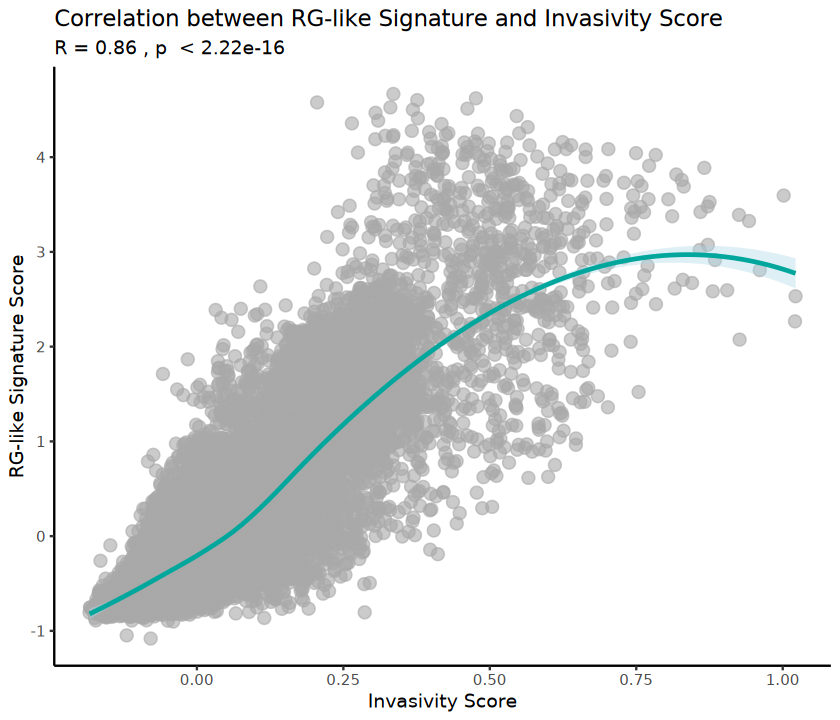

In [36]:
metadata <- FetchData(malignant, vars = c("RG_like1", "invasiveness1"))

# Subset the metadata to 50% of the cells
set.seed(123) # Set seed for reproducibility
metadata_subset <- metadata[sample(1:nrow(metadata), size = floor(0.1 * nrow(metadata))), ]

# Recalculate correlation using the subset data
correlation <- cor.test(metadata_subset$RG_like1, metadata_subset$invasiveness1)
R_value <- correlation$estimate
p_value <- correlation$p.value

# Print R and p-value
cat("Correlation coefficient (R):", R_value, "\n")
cat("p-value:", p_value, "\n")

# Create scatter plot with subset data
plot <- ggplot(metadata_subset, aes(x = invasiveness1, y = RG_like1)) +
  geom_point(color = "#a9a8a8", alpha = 0.6, size=3) +
  geom_smooth(method = "loess", formula = 'y ~ x', color = "#01a79c", , 
    fill = "lightblue") +
  labs(
    title = "Correlation between RG-like Signature and Invasivity Score",
    subtitle = paste("R =", round(R_value, 2), ", p ", format.pval(p_value)),
    x = "Invasivity Score",
    y = "RG-like Signature Score"
  ) +
  theme_classic()

# Show plot
print(plot)

In [14]:
gene_set <- as.data.frame(MP_list)[[2]]

In [15]:
malignant <-AddModuleScore(
    obj = malignant,
    features = invasiveness_sig,
    ncores = 12,
    name = 'invasiveness'
    )

malignant <- AddModuleScore(
    obj = malignant,
    features = list(gene_set),
    name = 'OPC_like',
    ncores = 12,
    )

Warning message:
“The following features are not present in the object: AC114730.3, CASC5, CCDC109B, CYR61, FAM64A, KCNQ1OT1, KIAA0101, LINC00152, LSMD1, MALAT1, MIR4435-1HG, NGFRAP1, PRR24, SGOL1, SGOL2, not searching for symbol synonyms”


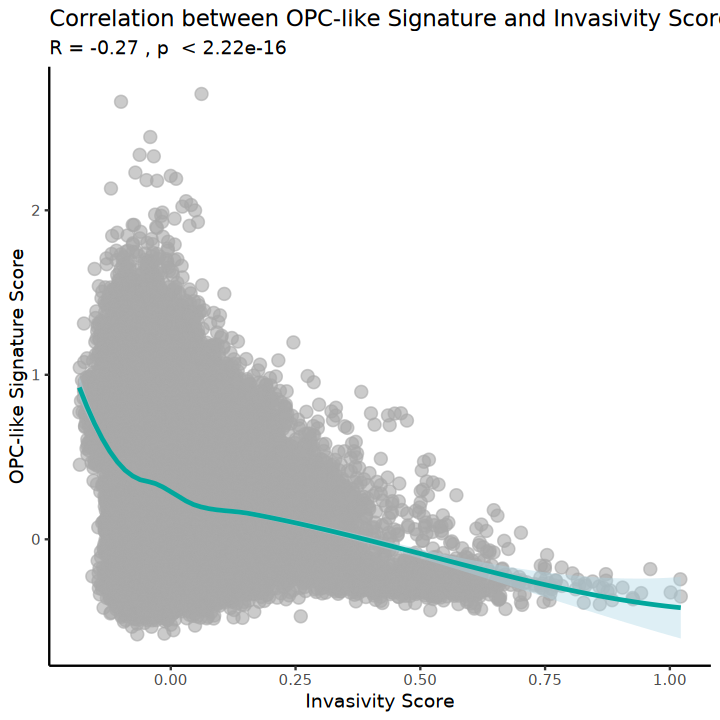

In [17]:
# metadata <- FetchData(malignant, vars = c("OPC_like1", "invasiveness1"))

# # Subset the metadata to 50% of the cells
# set.seed(123) # Set seed for reproducibility
# metadata_subset <- metadata[sample(1:nrow(metadata), size = floor(0.1 * nrow(metadata))), ]

# # Recalculate correlation using the subset data
# correlation <- cor.test(metadata_subset$OPC_like1, metadata_subset$invasiveness1)
# R_value <- correlation$estimate
# p_value <- correlation$p.value

# # Print R and p-value
# cat("Correlation coefficient (R):", R_value, "\n")
# cat("p-value:", p_value, "\n")


options(repr.plot.height = 6, repr.plot.width = 6)
# Create scatter plot with subset data
plot <- ggplot(metadata_subset, aes(x = invasiveness1, y = OPC_like1)) +
  geom_point(color = "#a9a8a8", alpha = 0.6, size=3) +
  geom_smooth(method = "loess", formula = 'y ~ x', color = "#01a79c", , 
    fill = "lightblue") +
  labs(
    title = "Correlation between OPC-like Signature and Invasivity Score",
    subtitle = paste("R =", round(R_value, 2), ", p ", format.pval(p_value)),
    x = "Invasivity Score",
    y = "OPC-like Signature Score"
  ) +
  theme_classic()

# Show plot
print(plot)

In [18]:
ggsave('figures/corr_invasivity_OPC_like.pdf')

Saving 6.67 x 6.67 in image
